### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

###  Load Dataset

In [4]:
df = pd.read_csv('raw_user_profiles.csv')


In [6]:
df.head()

,user_id,username,full_name,first_name,last_name,email,creation_date,account_age_days,profile_completeness,home_country,...,is_private,is_verified,profile_picture,profile_banner,has_bio,has_website,has_location,account_type,is_fake,language_preference
0,b74f2b71-054b-4f53-a3af-7af090c283d3,peterkonda,Peter Konda,Peter,Konda,peterkonda@icloud.com,2024-09-11,211,0.665228,Burundi,...,False,False,True,True,False,False,True,active_user,False,ja
1,ce876a7e-6760-4978-a62b-683102cef949,jhoffman600,Jesse Hoffman,Jesse,Hoffman,jhoffman@yahoo.com,2024-07-19,265,0.688153,Djibouti,...,True,False,True,False,False,False,False,active_user,False,en
2,a45c299b-37a1-4dea-922c-432d3dc28c63,official_billgates634,Dörte Bassi,Dörte,Bassi,official_billgates634official@mail.ru,2024-12-30,101,0.817443,United Kingdom,...,False,True,True,False,True,False,False,impersonation,True,hi
3,4af989e7-368c-4b4b-a071-c5e9b3f19f48,hassan82,Hassan Bora,Hassan,Bora,hassanb@yahoo.com,2023-05-07,704,0.386452,Martinique,...,False,False,True,True,False,False,False,active_user,False,en
4,087382bb-cace-4128-82ab-f133501759fb,facts124568,Priya Étienne,Priya,Étienne,facts124568official@yahoo.com,2025-02-11,58,0.689859,United States,...,False,False,True,False,False,False,False,bot,True,en


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               5000 non-null   object 
 1   username              5000 non-null   object 
 2   full_name             5000 non-null   object 
 3   first_name            5000 non-null   object 
 4   last_name             5000 non-null   object 
 5   email                 5000 non-null   object 
 6   creation_date         5000 non-null   object 
 7   account_age_days      5000 non-null   int64  
 8   profile_completeness  5000 non-null   float64
 9   home_country          5000 non-null   object 
 10  home_region           5000 non-null   object 
 11  home_city             5000 non-null   object 
 12  followers_count       5000 non-null   int64  
 13  following_count       5000 non-null   int64  
 14  posts_count           5000 non-null   int64  
 15  is_private           

In [10]:
df.describe()

,account_age_days,profile_completeness,followers_count,following_count,posts_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,700.126800,0.647921,3303.938800,107.967400,26.256800
std,592.343034,0.202552,33018.900333,232.881659,12.064757
min,1.000000,0.300178,5.000000,5.000000,5.000000
25%,109.000000,0.474663,16.000000,12.000000,17.000000
50%,597.500000,0.648244,66.000000,38.500000,25.000000
75%,1165.250000,0.821105,342.250000,108.000000,35.000000
max,2190.000000,0.999779,1000000.000000,6712.000000,60.000000


In [12]:
df.tail()

,user_id,username,full_name,first_name,last_name,email,creation_date,account_age_days,profile_completeness,home_country,...,is_private,is_verified,profile_picture,profile_banner,has_bio,has_website,has_location,account_type,is_fake,language_preference
4995,bf745540-6aa4-4513-b6f8-14f680d303b5,dominic_green881,Dominic Green,Dominic,Green,dgreen@icloud.com,2023-02-23,777,0.709773,Malaysia,...,False,False,True,True,True,True,True,active_user,False,hi
4996,222d4b36-8538-429c-8770-c96cc6a12a4f,robert.laurent,Robert Laurent,Robert,Laurent,robert.laurent@yahoo.com,2024-07-25,259,0.576957,Reino Unido de Gran Bretaña e Irlanda del Norte,...,True,False,True,True,True,False,True,active_user,False,hi
4997,57059a30-3986-45b5-a806-ac4807844c9f,the_deborah_agency229,Deborah Coulon,Deborah,Coulon,info@enterprise.com,2022-02-17,1148,0.475707,Uruguay,...,False,True,True,True,True,True,True,business,False,pt
4998,2d918c56-8a29-4b25-a149-b3f47402edf0,dominiqueblackburn204,Dominique Blackburn,Dominique,Blackburn,dominiqueb@yahoo.com,2024-12-26,105,0.715105,Brazil,...,False,False,True,True,True,False,True,casual_user,False,es
4999,829f4815-e269-437f-aacb-f04ac4d171cf,jennings2,Julie Jennings,Julie,Jennings,julie.jennings@mail.com,2023-04-23,718,0.516969,Iran,...,False,False,True,True,False,True,True,casual_user,False,es


In [14]:
df.isnull().sum()

user_id                 0
username                0
full_name               0
first_name              0
last_name               0
email                   0
creation_date           0
account_age_days        0
profile_completeness    0
home_country            0
home_region             0
home_city               0
followers_count         0
following_count         0
posts_count             0
is_private              0
is_verified             0
profile_picture         0
profile_banner          0
has_bio                 0
has_website             0
has_location            0
account_type            0
is_fake                 0
language_preference     0
dtype: int64

In [16]:
df['followers_following_ratio'] = df['followers_count'] / (df['following_count'] + 1)


In [18]:
features = [
    'followers_count',
    'following_count',
    'posts_count',
    'account_age_days',
    'profile_completeness',
    'is_private',
    'is_verified',
    'profile_picture',
    'profile_banner',
    'has_bio',
    'has_website',
    'has_location',
    'account_type',
    'followers_following_ratio' 
]
target = 'is_fake'

### Split dataset into train and test

In [21]:
X = df[features]
y = df[target]

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
df['account_type'] = df['account_type'].map({
    'active_user': 0,
    'bot': 1,
    'suspicious': 2

})

In [25]:
if X_train['account_type'].dtype == 'object':
    print("Unique values in account_type:", X_train['account_type'].unique())

    mapping = {
        'active_user': 0,
        'bot': 1,
        'suspicious': 2,
        'business': 3, 
        
    }

    X_train['account_type'] = X_train['account_type'].map(mapping)
    X_test['account_type'] = X_test['account_type'].map(mapping)

    X_train['account_type'] = X_train['account_type'].fillna(0).astype(int)
    X_test['account_type'] = X_test['account_type'].fillna(0).astype(int)


Unique values in account_type: ['business' 'hate_speech' 'active_user' 'hobbyist' 'bot' 'impersonation'
 'phishing' 'porn_scam' 'casual_user' 'influencer' 'community'
 'crypto_scam' 'news_updates']


In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

In [31]:
y_pred = rf.predict(X_test_scaled)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.98      0.98       756
        True       0.93      0.93      0.93       244

    accuracy                           0.96      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.96      0.96      0.96      1000

Confusion Matrix:
 [[739  17]
 [ 18 226]]


### Decision Tree

In [34]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

###  Support Vector Machine

In [37]:

svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

###  Evaluation Function

In [40]:

def evaluate_model(name, y_true, y_pred, model=None):
    print(f"\n🔍 Evaluation for {name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    if model:
        y_prob = model.predict_proba(X_test)[:,1]
        print("AUC-ROC:", roc_auc_score(y_true, y_prob))
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_true, y_prob):.2f})')

### Plot ROC Curve for all models

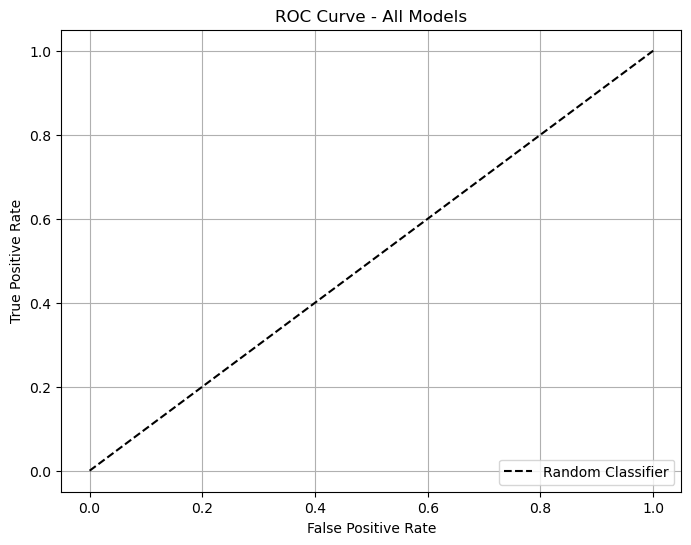

In [43]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


###  ROC Curve

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


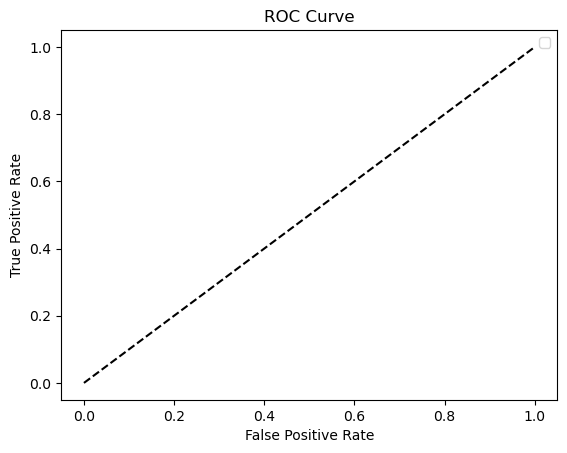

In [46]:

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [48]:
def predict_fake_profile():
    input_data = {
        'followers_count': int(input("Followers Count: ")),
        'following_count': int(input("Following Count: ")),
        'posts_count': int(input("Posts Count: ")),
        'account_age_days': int(input("Account Age (days): ")),
        'profile_completeness': float(input("Profile Completeness (0 to 1): ")),
        'is_private': int(input("Is Private (1/0): ")),
        'is_verified': int(input("Is Verified (1/0): ")),
        'profile_picture': int(input("Has Profile Picture (1/0): ")),
        'profile_banner': int(input("Has Profile Banner (1/0): ")),
        'has_bio': int(input("Has Bio (1/0): ")),
        'has_website': int(input("Has Website (1/0): ")),
        'has_location': int(input("Has Location (1/0): ")),
        'account_type': int(input("Account Type (active=0, bot=1, suspicious=2): "))
    }
    ratio = input_data['followers_count'] / (input_data['following_count'] + 1)
    input_data['followers_following_ratio'] = ratio
    input_df = pd.DataFrame([input_data])[features]
    input_scaled = scaler.transform(input_df)
    prediction = rf.predict(input_scaled)[0]
    print("\n Prediction:")
    if prediction == 1:
        print("🚨 This profile is likely FAKE.")
    else:
        print(" This profile appears to be GENUINE.")

In [50]:
predict_fake_profile()


Followers Count:  20000
Following Count:  323
Posts Count:  234
Account Age (days):  190
Profile Completeness (0 to 1):  0
Is Private (1/0):  1
Is Verified (1/0):  1
Has Profile Picture (1/0):  1
Has Profile Banner (1/0):  1
Has Bio (1/0):  1
Has Website (1/0):  1
Has Location (1/0):  1
Account Type (active=0, bot=1, suspicious=2):  0



 Prediction:
 This profile appears to be GENUINE.
